# Two nodes - Atom loading analysis
Valid for experiments after 2026-06~~ with BS in BSA

Since 2025-06-15 We are running experiments with BS in BSA. Now both nodes are being readout with All SPCMs at the same time with two_atom_threshold

In [10]:
date_filters = ["2026-07-14"]


from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints
import math
import itertools

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan","Microwaves_scans","MicrowaveScanOptimizer"], # find files containing any of these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

found 10 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\10\000038005-GeneralVariableScan_Two_nodes_atom_loading_scan_over_dummy_variable.h5) scanned over dummy_variable
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\10\000038007-GeneralVariableScan.h5) scanned over dummy_variable
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\10\000038011-GeneralVariableScan.h5) scanned over dummy_variable
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\10\000038011-GeneralVariableScan_Two_nodes_atom_loading_scan_over_dummy_variable.h5) scanned over dummy_variable
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\11\000038014-GeneralVariableScan.h5) scanned over dummy_variable
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-07-14\11\000038014-GeneralVariableScan_atom_loading_2_scan_over_dummy_variable.h5) scanned over dummy_variab

## Combine files and fit

experiment: atom_loading_2_experiment
override: {'t_FORT_drop':10*us, 'f_microwaves_dds': self.f_microwaves_00_dds,'t_microwave_pulse':self.t_microwave_00_pulse,'p_excitation':-4.0, 't_pumping':100*us, 't_delay_in_bob_mu': 189 ,  't_PGC_after_loading':0.6*ms, 't_recooling_after_first_shot':0*ms, 'n_excitation_attempts':2, 'p_cooling_DP_RO': 0.8,'t_recooling':1*ms, 'atom_check_every_n':50, 'recool_every_n_OP':1, 't_photon_collection_time':150*ns}
# of iterations:  100
center=57.7994, sigma=10240000.4124, depth=1.0000


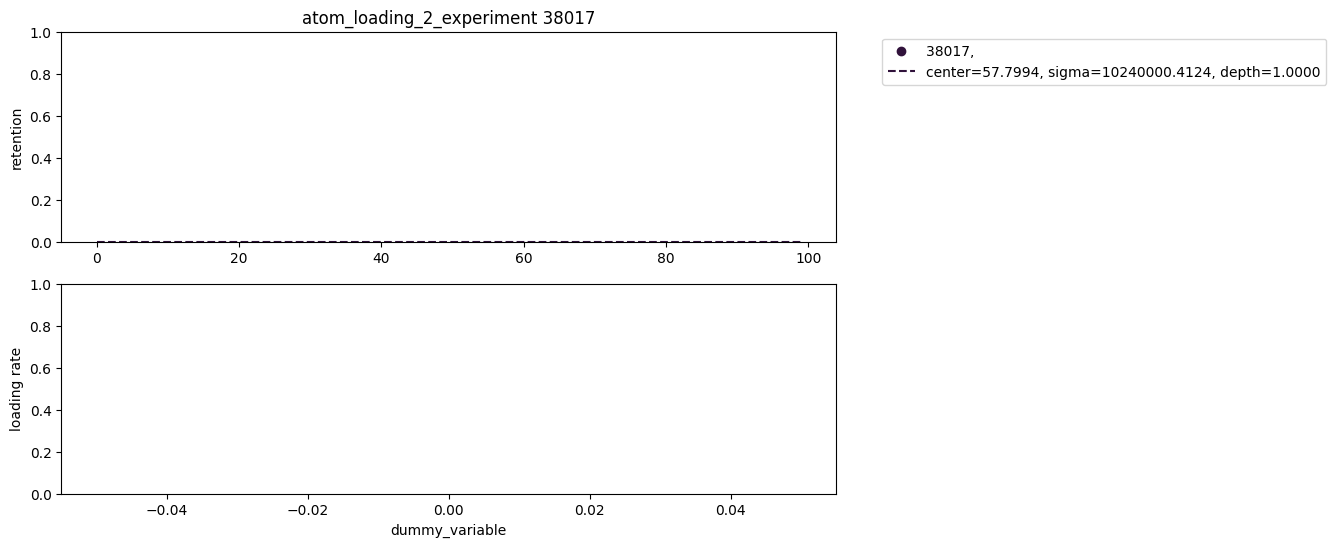

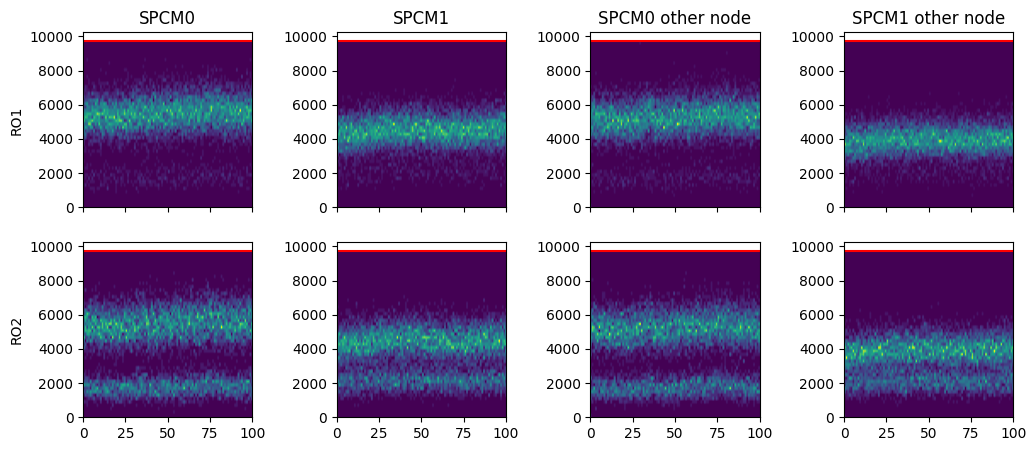

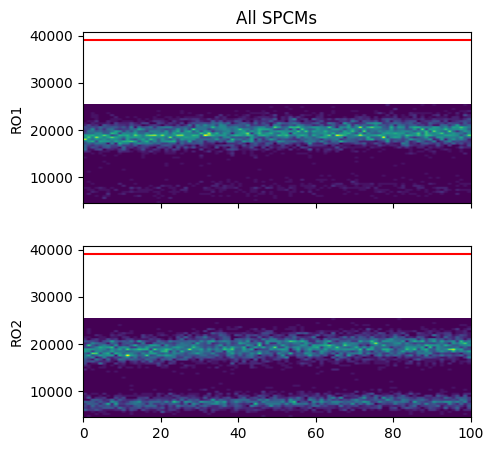

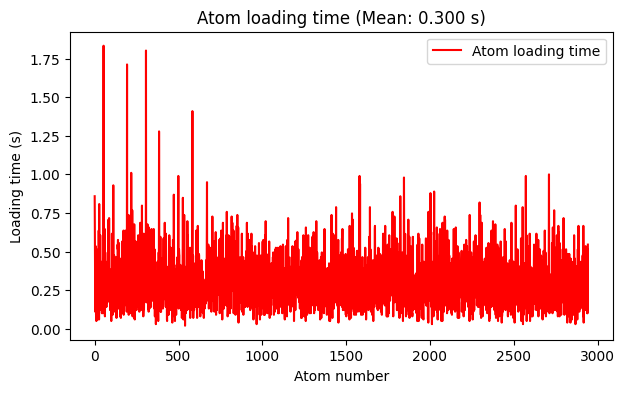

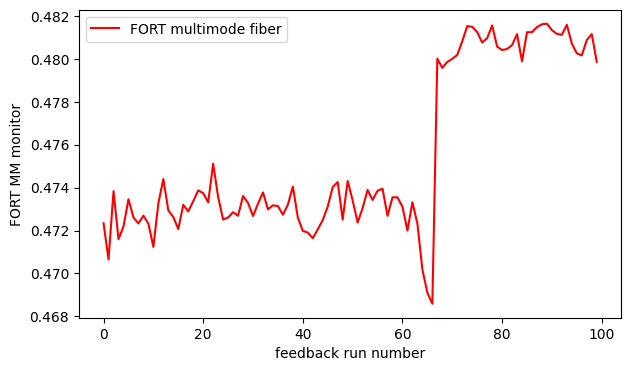

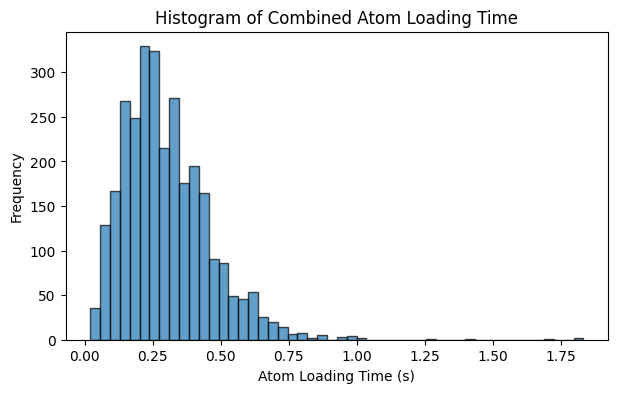

In [11]:
### the file(s) to analyze:
file_indices = {
    # 3:''   ##10ms
    # 5:'' ##10ms long scan

    9:''
} 

# file_indices = {i: '' for i in range(0, 17, 2)}

compare = True # compare multiple files in the same retention and loading plots

otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False

user_set_manual_threshold = 17000
manual_threshold = False


showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = True

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
SPCM0_OtherNode_RO1_hists = []
SPCM0_OtherNode_RO2_hists = []
SPCM1_OtherNode_RO1_hists = []
SPCM1_OtherNode_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
AllSPCMs_RO1_hists = []
AllSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        # thresh = threshold_otsu(BothSPCMs_RO1)
        thresh = threshold_otsu(AllSPCMs_RO1)

        print("threshold_otsu: ", thresh)
    elif manual_threshold:
        cutoff1 = cutoff2 = user_set_manual_threshold * t_SPCM_first_shot
    else:
        # cutoff1 = cutoff2 = 15000 * t_SPCM_first_shot

        # cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot
        cutoff1 = cutoff2 = two_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    # retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(AllSPCMs_RO1, AllSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    # ### show historam of first_shot and second_shot
    # histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    # histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot


    ### Histogram boundaries for individual SPCMs
    single_hist_sources = [
        np.asarray(SPCM0_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM0_OtherNode_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_OtherNode_RO1) / t_SPCM_first_shot,
    
        np.asarray(SPCM0_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM0_OtherNode_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_OtherNode_RO2) / t_SPCM_second_shot,
    ]
    
    single_hist_sources = [x.ravel() for x in single_hist_sources if x.size > 0]
    
    histMin_single = min(np.min(x) for x in single_hist_sources)
    histMax_single = max(np.max(x) for x in single_hist_sources)
    
    
    ### Histogram boundaries for AllSPCMs
    all_hist_sources = [
        np.asarray(AllSPCMs_RO1) / t_SPCM_first_shot,
        np.asarray(AllSPCMs_RO2) / t_SPCM_second_shot,
    ]
    
    all_hist_sources = [x.ravel() for x in all_hist_sources if x.size > 0]
    
    histMin_all = min(np.min(x) for x in all_hist_sources)
    histMax_all = max(np.max(x) for x in all_hist_sources)


    
    if showhist:
        bins_single = np.linspace(histMin_single, histMax_single, 50)
        bins_all = np.linspace(histMin_all, histMax_all, 50)
    
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO1_hists.append(
            [np.histogram(SPCM0_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO2_hists.append(
            [np.histogram(SPCM0_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO1_hists.append(
            [np.histogram(SPCM1_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO2_hists.append(
            [np.histogram(SPCM1_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO1_hists.append(
            [np.histogram(AllSPCMs_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO2_hists.append(
            [np.histogram(AllSPCMs_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    ### Individual SPCM plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5), sharex=True)
    ax, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.ravel()

    ### RO1: SPCM0
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower',
                    extent=[0, iterations, histMin_single, histMax_single])
    ax.set_ylabel("RO1")
    ax.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### RO1: SPCM1
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax2.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### RO1: SPCM0 Other Node
    cax3 = ax3.imshow(np.array(SPCM0_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax3.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("SPCM0 other node")

    ### RO1: SPCM1 Other Node
    cax4 = ax4.imshow(np.array(SPCM1_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax4.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')
    ax4.set_title("SPCM1 other node")


    ### RO2: SPCM0
    cax5 = ax5.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax5.set_ylabel("RO2")
    ax5.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax5.set_aspect('auto')

    ### RO2: SPCM1
    cax6 = ax6.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax6.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax6.set_aspect('auto')

    ### RO2: SPCM0 Other Node
    cax7 = ax7.imshow(np.array(SPCM0_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax7.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax7.set_aspect('auto')

    ### RO2: SPCM1 Other Node
    cax8 = ax8.imshow(np.array(SPCM1_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax8.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax8.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)


    ### All SPCMs plotted separately
    fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
    ax_all1, ax_all2 = axes_all.ravel()

    ### RO1: All SPCMs
    cax_all1 = ax_all1.imshow(np.array(AllSPCMs_RO1_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all1.set_ylabel("RO1")
    ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax_all1.set_aspect('auto')
    ax_all1.set_title("All SPCMs")

    ### RO2: All SPCMs
    cax_all2 = ax_all2.imshow(np.array(AllSPCMs_RO2_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all2.set_ylabel("RO2")
    ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
    ax_all2.set_aspect('auto')

    plt.subplots_adjust(hspace=0.25)

plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = [t for loading_times in all_atom_loading_times for t in loading_times]
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()



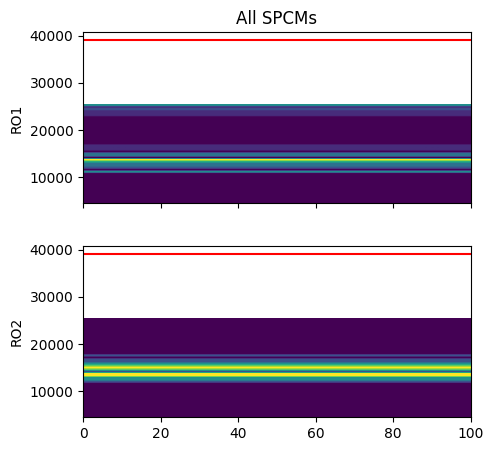

In [12]:
AllSPCMs_chopped_RO_alice_hist = []
AllSPCMs_chopped_RO_bob_hist = []


AllSPCMs_chopped_RO_alice_hist.append(
    [np.histogram(AllSPCMs_chopped_RO_alice_current_iteration[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                  bins=bins_all)[0]
     for i in range(1)]
)

AllSPCMs_chopped_RO_bob_hist.append(
    [np.histogram(AllSPCMs_chopped_RO_bob_current_iteration[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                  bins=bins_all)[0]
     for i in range(1)]
)

### All SPCMs plotted separately
fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
ax_all1, ax_all2 = axes_all.ravel()

### RO1: All SPCMs
cax_all1 = ax_all1.imshow(np.array(AllSPCMs_chopped_RO_alice_hist[0]).transpose(), origin='lower',
                          extent=[0, iterations, histMin_all, histMax_all])
ax_all1.set_ylabel("RO1")
ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
ax_all1.set_aspect('auto')
ax_all1.set_title("All SPCMs")

### RO2: All SPCMs
cax_all2 = ax_all2.imshow(np.array(AllSPCMs_chopped_RO_bob_hist[0]).transpose(), origin='lower',
                          extent=[0, iterations, histMin_all, histMax_all])
ax_all2.set_ylabel("RO2")
ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
ax_all2.set_aspect('auto')

plt.subplots_adjust(hspace=0.25)

In [4]:
AllSPCMs_chopped_RO_alice_current_iteration

array([  0, 266, 228, 118, 129, 232,  98, 245, 221, 227, 201, 234, 242,
       112, 239, 224, 107, 120, 218, 217, 260, 225, 225, 222, 257, 220,
       213, 146, 102, 240, 222, 209, 239, 231, 218, 225, 108, 210, 226,
       226, 115, 246, 231, 122, 240, 209, 237, 244, 230, 223, 240, 230,
       230, 223, 126, 256, 273, 216, 236, 231, 248, 237, 126, 122, 239,
       242, 234, 226, 130, 116, 247, 220, 225, 221, 234, 140, 259, 233,
       242, 247, 233, 141, 138, 118, 259, 252, 257, 130, 247, 210, 217,
       264, 235, 227, 232, 232, 104, 228, 134, 255, 120], dtype=int32)